In [ ]:
!gcloud auth application-default login

In [ ]:
!gcloud auth login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=32555940559.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fappengine.admin+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcompute+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=UiDTZiS2COSkwLlSyy0l1pVKoF8Yfg&access_type=offline&code_challenge=4jMAWGLzSEe-ozTnSiVWYKCSv6hg9PyZzX727eiHbYk&code_challenge_method=S256


You are now logged in as [yt4@sanger.ac.uk].
Your current project is [open-targets-genetics-dev].  You can change this setting by running:
  $ gcloud config set project PROJECT_ID


Updates are available for some Google Cloud CLI components.  To install them,
please run:
  $ gcloud components update



In [3]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize":"2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()

session= GentropySession()


path_to_release_folder="gs://open-targets-data-releases/25.03/"
#path_to_release_folder="gs://open-targets-pre-data-releases/24.12-uo_test-3/output/genetics/parquet/"
#path_to_release_folder="gs://ot_orchestration/releases/25.02_freeze1/"

si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")
sl=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")

Loading BokehJS ...

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/25 14:45:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/04/25 14:45:58 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/04/25 14:45:58 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


# Scaled betas

In [4]:
df=session.spark.read.parquet("gs://genetics-portal-dev-analysis/ss60/gentropy-manuscript/chapters/variant-effect-prediction/rescaled-betas.parquet").cache()

In [5]:
df.count()

2621048

In [6]:
df.printSchema()

root
 |-- variantId: string (nullable = true)
 |-- studyId: string (nullable = true)
 |-- studyLocusId: string (nullable = true)
 |-- beta: double (nullable = true)
 |-- zScore: double (nullable = true)
 |-- pValueMantissa: float (nullable = true)
 |-- pValueExponent: integer (nullable = true)
 |-- standardError: double (nullable = true)
 |-- finemappingMethod: string (nullable = true)
 |-- studyType: string (nullable = true)
 |-- credibleSetSize: integer (nullable = true)
 |-- posteriorProbability: double (nullable = true)
 |-- nSamples: integer (nullable = true)
 |-- nControls: integer (nullable = true)
 |-- nCases: integer (nullable = true)
 |-- majorPopulation: struct (nullable = true)
 |    |-- ldPopulation: string (nullable = true)
 |    |-- relativeSampleSize: double (nullable = true)
 |-- allelefrequencies: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- populationName: string (nullable = true)
 |    |    |-- alleleFrequency: double (nulla

In [7]:
df.show(2,truncate=False)

+----------------+----------------------------------------------------------------------+--------------------------------+--------+------+--------------+--------------+-------------+-----------------+---------+---------------+--------------------+--------+---------+------+---------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------+-------------------------------+------------------+----------------------------------------------------------------+------------------------------------------------------------------------------------------------------------+
|variantId       |studyId                                                               |studyLocusId                    |beta 

In [ ]:
df_filtered=(df.filter(f.col("studyType")=="gwas")
    .filter((f.col("majorPopulationMAF").isNotNull())&
    (f.col("majorPopulationMAF")>=0.0001)&
     (f.col("rescaledStatistics.estimatedBeta")<=3) &
     (f.col("rescaledStatistics.estimatedBeta")>=-3))
     ).cache()

In [ ]:
df_filtered.count()

556652

In [ ]:
df_filtered.show(1)

+----------------+------------+--------------------+-------------------+------------------+--------------+--------------+-------------+-----------------+---------+---------------+--------------------+--------+---------+------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+
|       variantId|     studyId|        studyLocusId|               beta|            zScore|pValueMantissa|pValueExponent|standardError|finemappingMethod|studyType|credibleSetSize|posteriorProbability|nSamples|nControls|nCases|     majorPopulation|   allelefrequencies|           vepEffect|   majorPopulationAF| majorPopulationMAF|    leadVariantStats|  rescaledStatistics|
+----------------+------------+--------------------+-------------------+------------------+--------------+--------------+-------------+-----------------+---------+---------------+--------------------+--------+---------+------+--------------------+-------

In [ ]:
from scipy.stats import pearsonr

# Collect the two columns into a Pandas DataFrame
pandas_df = df_filtered.select("vepEffect.normalisedScore", "majorPopulationMAF").toPandas()

# Extract the two columns as arrays
x = pandas_df["normalisedScore"]
y = pandas_df["majorPopulationMAF"]

# Calculate the Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(x, y)

# Print the results
print(f"Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

Correlation Coefficient: -0.17455570062736306
P-value: 0.0


In [ ]:
from scipy.stats import pearsonr

# Collect the two columns into a Pandas DataFrame
pandas_df = df_filtered.select("vepEffect.normalisedScore", "rescaledStatistics.estimatedBeta").toPandas()

# Extract the two columns as arrays
x = pandas_df["normalisedScore"]
y = pandas_df["estimatedBeta"]

y=np.abs(y)

# Calculate the Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(x, y)

# Print the results
print(f"Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

Correlation Coefficient: 0.053542002079905095
P-value: 0.0


In [ ]:
from scipy.stats import pearsonr

# Collect the two columns into a Pandas DataFrame
pandas_df = df_filtered.select("vepEffect.normalisedScore", "posteriorProbability").toPandas()

# Extract the two columns as arrays
x = pandas_df["normalisedScore"]
y = pandas_df["posteriorProbability"]

# Calculate the Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(x, y)

# Print the results
print(f"Correlation Coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

Correlation Coefficient: 0.14912251643606794
P-value: 0.0


In [ ]:
pandas_df = df_filtered.select("vepEffect.normalisedScore", "rescaledStatistics.estimatedBeta","majorPopulationMAF","posteriorProbability").toPandas()

In [ ]:
pandas_df

,normalisedScore,estimatedBeta,majorPopulationMAF,posteriorProbability
0,0.1,0.033563,0.441917,1.000000
1,0.1,-0.019436,0.263927,0.097374
2,0.1,0.084838,0.016009,0.999793
3,0.1,0.079233,0.016009,0.949409
4,0.1,-0.031589,0.386189,0.099316
...,...,...,...,...
556647,0.0,-0.133506,0.005846,1.000000
556648,0.1,0.061120,0.340000,0.045344
556649,0.1,-0.088602,0.264814,0.253484
556650,0.1,0.079953,0.309175,0.445865


In [ ]:
pandas_df.to_csv("vep_effects.csv", index=False)

25/04/17 17:53:45 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 988264 ms exceeds timeout 120000 ms
25/04/17 17:53:45 WARN SparkContext: Killing executors is not supported by current scheduler.
25/04/17 18:09:38 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at o

In [ ]:
import pandas as pd
import statsmodels.api as sm

pandas_df = df_filtered.select("vepEffect.normalisedScore", "rescaledStatistics.estimatedBeta","majorPopulationMAF","posteriorProbability").toPandas()
# Assuming pandas_df is your DataFrame
# Define the dependent variable (y) and independent variables (x1, x2)
y = pandas_df["normalisedScore"]
x1 = pandas_df["estimatedBeta"]
x2 = pandas_df["majorPopulationMAF"]
x3= pandas_df["posteriorProbability"]

# Combine x1 and x2 into a single DataFrame for predictors
X = pd.DataFrame({"x1": x1, "x2": x2})

# Add a constant term for the intercept
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Print the summary of the model
print(model.summary())

# Extract betas (coefficients) and p-values
betas = model.params
p_values = model.pvalues

# Print betas and p-values
print("Betas (coefficients):")
print(betas)
print("\nP-values:")
print(p_values)

ModuleNotFoundError: No module named 'statsmodels'

In [8]:
disease_index_path=path_to_release_folder+"output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

In [9]:
all_mesurments = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,efo_ids=["EFO_0001444"]
)

In [10]:
len(all_mesurments)

8293

In [11]:
df=df.join(si.df.select("studyId","diseaseIds"), on="studyId", how="left").cache()
df.count()

2621048

In [ ]:
df.filter(f.col("studyId")=="GCST006672").show(1)

+----------+---------------+--------------------+--------+------+--------------+--------------+-------------+-----------------+---------+---------------+--------+---------+------+---------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+-------------+
|   studyId|      variantId|        studyLocusId|    beta|zScore|pValueMantissa|pValueExponent|standardError|finemappingMethod|studyType|credibleSetSize|nSamples|nControls|nCases|majorPopulation|   allelefrequencies|           vepEffect|   majorPopulationAF| majorPopulationMAF|    leadVariantStats|  rescaledStatistics|   diseaseIds|
+----------+---------------+--------------------+--------+------+--------------+--------------+-------------+-----------------+---------+---------------+--------+---------+------+---------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+----------

In [12]:
exploded_df = df.select("studyId","diseaseIds").withColumn("diseaseId", f.explode(f.col("diseaseIds"))).cache()
exploded_df.count()

628061

In [13]:
exploded_df=exploded_df.filter(f.col("diseaseId").isin(all_mesurments)).cache()
exploded_df.count()

533323

In [14]:
studyIds_measuments=exploded_df.select("studyId").distinct()

In [15]:
studyIds_measuments.count()

29961

In [16]:
# Perform a left anti join to remove overlapping rows
filtered_df = df.join(studyIds_measuments, on="studyId", how="left_anti").cache()

# Show the resulting DataFrame
filtered_df.count()

2124818

In [ ]:
filtered_df = filtered_df.filter(
    (f.col("rescaledStatistics.prev").isNotNull()) & 
    (~f.isnan(f.col("rescaledStatistics.prev")))&
     (f.col("rescaledStatistics.estimatedBeta")<=1) &
     (f.col("rescaledStatistics.estimatedBeta")>=-1)&
      (f.col("finemappingMethod")=="PICS")&
    (f.col("beta")<=1) &
    (f.col("beta")>=-1)
)

filtered_df.count()

17028

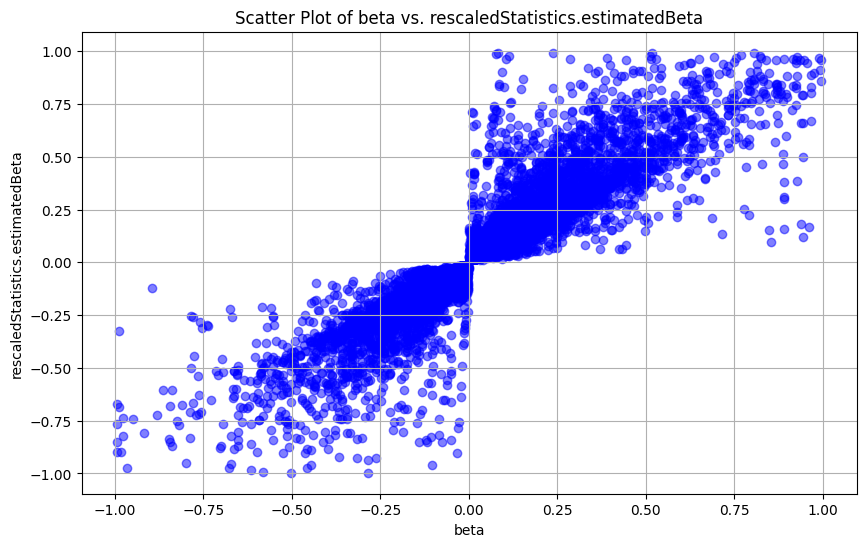

In [ ]:
import matplotlib.pyplot as plt

# Select the relevant columns and collect the data into a Pandas DataFrame
pandas_df = filtered_df.select("beta", "rescaledStatistics.estimatedBeta").toPandas()

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(pandas_df["beta"], pandas_df["estimatedBeta"], alpha=0.5, color='blue')
plt.title("Scatter Plot of beta vs. rescaledStatistics.estimatedBeta")
plt.xlabel("beta")
plt.ylabel("rescaledStatistics.estimatedBeta")
plt.grid(True)
plt.show()

In [ ]:
filtered_df.show(truncate=False)

+------------+----------------+--------------------------------+--------------------+------+--------------+--------------+-------------+-----------------+---------+---------------+--------+---------+------+-------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------+---------------------------------+--------------------+----------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------+---------------+
|studyId     |variantId       |studyLocusId                    |beta                |zScore|pValueMantissa|pValueExponent|standardE

In [ ]:
studIds_log_regr=["GCST003622","GCST000996"]

In [ ]:
filtered_df2=df.filter(f.col("studyId").isin(studIds_log_regr)).cache()
filtered_df2.show()

+----------+---------------+--------------------+--------------------+------+--------------+--------------+-------------+-----------------+---------+---------------+--------+---------+------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------+
|   studyId|      variantId|        studyLocusId|                beta|zScore|pValueMantissa|pValueExponent|standardError|finemappingMethod|studyType|credibleSetSize|nSamples|nControls|nCases|     majorPopulation|   allelefrequencies|           vepEffect|   majorPopulationAF|  majorPopulationMAF|    leadVariantStats|  rescaledStatistics|     diseaseIds|
+----------+---------------+--------------------+--------------------+------+--------------+--------------+-------------+-----------------+---------+---------------+--------+---------+------+--------------------+--------------------+--------------------+--------------------+---------------

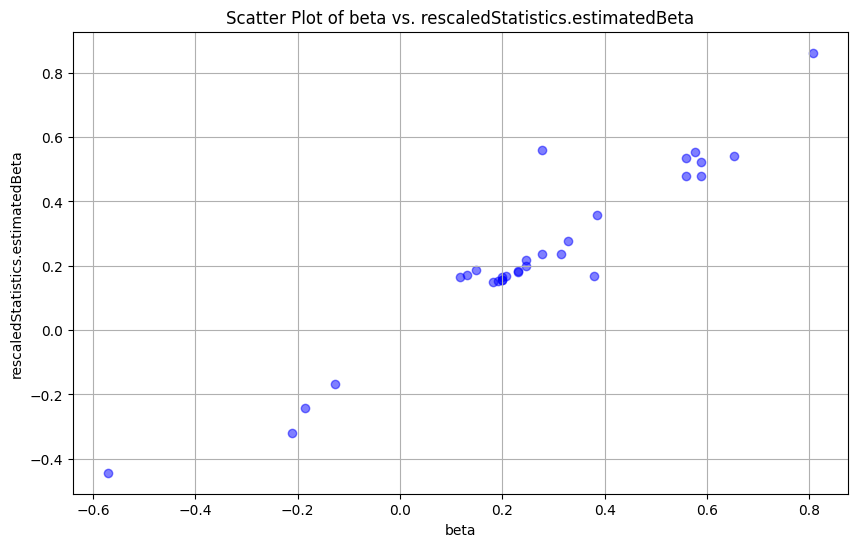

In [ ]:
import matplotlib.pyplot as plt

# Select the relevant columns and collect the data into a Pandas DataFrame
pandas_df = filtered_df2.select("beta", "rescaledStatistics.estimatedBeta").toPandas()

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(pandas_df["beta"], pandas_df["estimatedBeta"], alpha=0.5, color='blue')
plt.title("Scatter Plot of beta vs. rescaledStatistics.estimatedBeta")
plt.xlabel("beta")
plt.ylabel("rescaledStatistics.estimatedBeta")
plt.grid(True)
plt.show()

In [42]:
# Perform a left anti join to remove overlapping rows
filtered_df = df.join(studyIds_measuments, on="studyId", how="left_anti").cache()

# Show the resulting DataFrame
filtered_df.count()

25/04/25 15:05:28 WARN CacheManager: Asked to cache already cached data.


2124818

In [43]:
filtered_df = filtered_df.filter(
    (f.col("rescaledStatistics.prev").isNotNull())& 
    (~f.isnan(f.col("rescaledStatistics.prev")))&
    (f.col("nCases")<f.col("nControls"))&
     (f.col("rescaledStatistics.estimatedBeta")<=3) &
     (f.col("rescaledStatistics.estimatedBeta")>=-3)&
     (f.col("rescaledStatistics.prev")>=0.005)&
     (f.col("nSamples")>=10000)).cache()

filtered_df.count()

51345

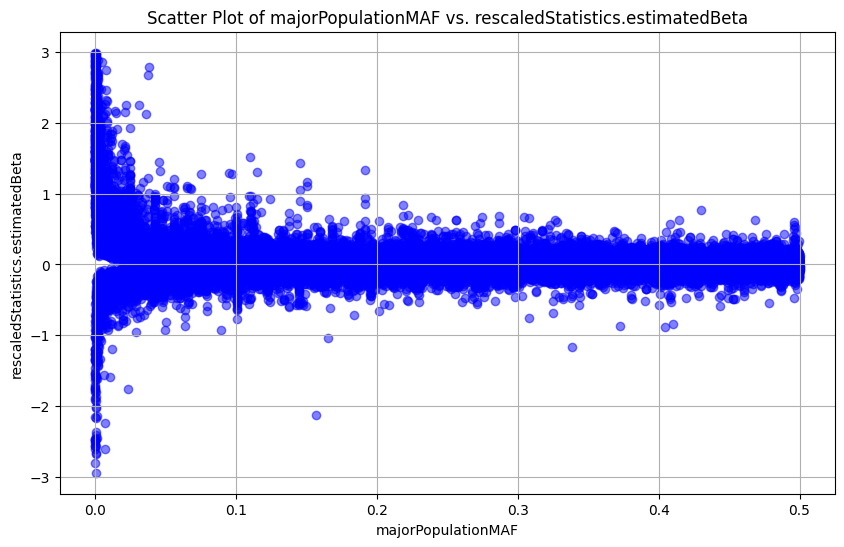

In [44]:
import matplotlib.pyplot as plt

# Select the relevant columns and collect the data into a Pandas DataFrame
pandas_df = filtered_df.select("majorPopulationMAF", "rescaledStatistics.estimatedBeta").toPandas()

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(pandas_df["majorPopulationMAF"], pandas_df["estimatedBeta"], alpha=0.5, color='blue')
plt.title("Scatter Plot of majorPopulationMAF vs. rescaledStatistics.estimatedBeta")
plt.xlabel("majorPopulationMAF")
plt.ylabel("rescaledStatistics.estimatedBeta")
plt.grid(True)
plt.show()

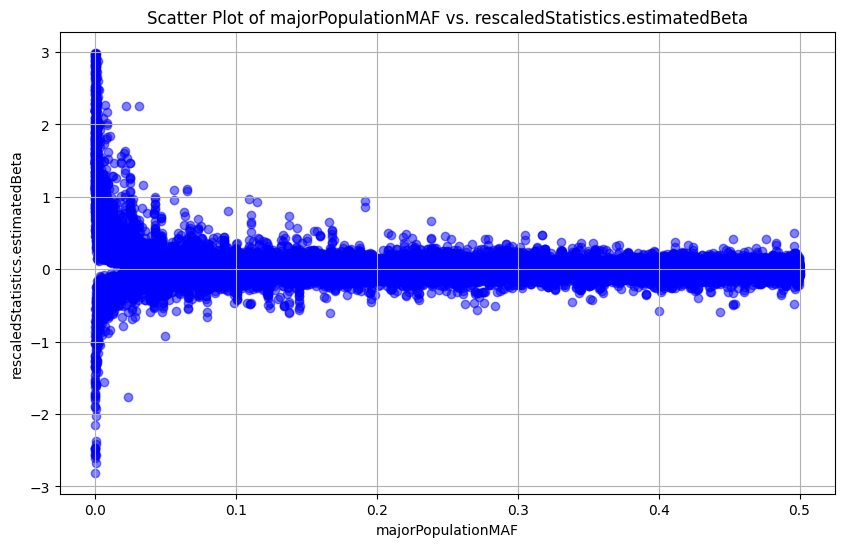

In [21]:
import matplotlib.pyplot as plt

# Select the relevant columns and collect the data into a Pandas DataFrame
pandas_df = filtered_df.select("majorPopulationMAF", "rescaledStatistics.estimatedBeta").toPandas()

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(pandas_df["majorPopulationMAF"], pandas_df["estimatedBeta"], alpha=0.5, color='blue')
plt.title("Scatter Plot of majorPopulationMAF vs. rescaledStatistics.estimatedBeta")
plt.xlabel("majorPopulationMAF")
plt.ylabel("rescaledStatistics.estimatedBeta")
plt.grid(True)
plt.show()

In [ ]:
filtered_df.filter((f.col("majorPopulationMAF")>=0.1)&(f.col("rescaledStatistics.estimatedBeta")>=1)).show(truncate=False)

+------------+---------------+--------------------------------+-------------------+------+--------------+--------------+-------------+-----------------+---------+---------------+--------+---------+------+-------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------------------------+--------------------------------+-------------------+------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------+---------------+
|studyId     |variantId      |studyLocusId                    |beta               |zScore|pValueMantissa|pValueExponent|standardError|finemappi

25/04/14 23:36:35 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 906178 ms exceeds timeout 120000 ms
25/04/14 23:36:35 WARN SparkContext: Killing executors is not supported by current scheduler.
25/04/14 23:36:38 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$